<a href="https://colab.research.google.com/github/JoseAlberto88/Predictive-Analytics-/blob/main/DAMO510_Summer26_Module_07_Reference_Solution(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAMO510 - Module 07: Introduction to Decision Trees
## Reference Solution

> **Assumption:** The supplied dataset is already cleaned and preprocessed, so no separate data-cleaning stage is included here.

### Objectives

1. Prepare the target and predictors and apply One-Hot Encoding without data leakage.

2. Build and compare Decision Tree, Random Forest, and Extreme Gradient Boosting (XGBoost) classifiers.

3. Evaluate models using confusion matrices, accuracy, F1 score, classification reports, and ROC/AUC.

- Examine feature importance.

- Investigate the effects of class imbalance and selected hyperparameters.

- Compare tree-based approaches with a logistic-regression baseline.

- Answer the reflection questions.



## Decision Tree:

Find a sequence of questions that progressively separates the classes.

## Random Forest:

Build many randomized Decision Trees and let them collectively decide.

## XGBoost:

Build trees sequentially, where each additional tree is chosen to improve the current ensemble's mistakes.

Your assignment intentionally moves through them in this order.

> First, Decision Trees are used to investigate splitting criteria, class balancing and complexity parameters.

> Then Random Forest demonstrates what happens when we replace one tree with an ensemble of randomized trees.

> Finally, XGBoost introduces a more sophisticated ensemble where trees are constructed sequentially, and your exercise specifically introduces scale_pos_weight to address class imbalance.

## 0. Install XGBoost if required

In [2]:
#Run this only if XGBoost is not already installed.
!pip install xgboost

## 1. Load Required Libraries

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score,
    roc_curve
)

## 2. Load the Dataset

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
DATA_FILE = '/content/drive/MyDrive/Predictive Analytics Course/PCOS_data_without_infertility_tailored_Cleaned.csv'
df = pd.read_csv(DATA_FILE)

print("Initial shape:", df.shape)
df.head()

Initial shape: (536, 36)


,PCOS_Diagnosis,Age,Body_Mass_Index,Blood_Type,Pulse_Rate,Respiratory_Rate,Hemoglobin,Cycle_Regularity,Cycle_Length,Marriage_History,...,Pimples,Fast_Food,Regular_Exercise,BP_Systolic,BP_Diastolic,Follicle_Count_Left,Follicle_Count_Right,Avg_Follicle_Size_Left,Avg_Follicle_Size_Right,Endometrium_Thickness
0,0,28,19.304017,15,78,22,10.48,2,5,7.0,...,0,1,0,110,80,3,3,18.0,18.0,8.5
1,0,36,24.921163,15,74,20,11.70,2,5,11.0,...,0,0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,25.270891,11,72,18,11.80,2,5,10.0,...,1,1,0,120,80,13,15,18.0,20.0,10.0
3,0,37,29.674945,13,72,20,12.00,2,5,4.0,...,0,0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,20.060954,11,72,18,10.00,2,5,1.0,...,0,0,0,120,80,3,4,16.0,14.0,7.0


In [17]:
df.columns

Index(['PCOS_Diagnosis', 'Age', 'Body_Mass_Index', 'Blood_Type', 'Pulse_Rate',
       'Respiratory_Rate', 'Hemoglobin', 'Cycle_Regularity', 'Cycle_Length',
       'Marriage_History', 'Pregnant', 'Abortions', 'Beta_HCG_1', 'Beta_HCG_2',
       'FSH_LH_Ratio', 'Waist_Hip_Ratio', 'TSH', 'AMH', 'Prolactin',
       'Vitamin_D3', 'Progesterone', 'Random_Blood_Sugar', 'Weight_Gain',
       'Hair_Growth', 'Skin_Darkening', 'Hair_Loss', 'Pimples', 'Fast_Food',
       'Regular_Exercise', 'BP_Systolic', 'BP_Diastolic',
       'Follicle_Count_Left', 'Follicle_Count_Right', 'Avg_Follicle_Size_Left',
       'Avg_Follicle_Size_Right', 'Endometrium_Thickness'],
      dtype='object')

## 3. Data Preparation

The target is `PCOS_Diagnosis`, where 1 represents PCOS and 0 represents no PCOS.

The train/test split is created **before** fitting the One-Hot Encoder. This is important because preprocessing should be learned only from the training data. `stratify=y` is used so the class proportions are preserved as closely as possible in both the training and testing sets(we did discuss these last week).

In [18]:
y = df["PCOS_Diagnosis"]
X = df.drop(columns = ["PCOS_Diagnosis"])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 88,
    stratify = y
)

print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training shape: (428, 35)
Testing shape: (108, 35)

Training target distribution:
PCOS_Diagnosis
0    287
1    141
Name: count, dtype: int64

Testing target distribution:
PCOS_Diagnosis
0    73
1    35
Name: count, dtype: int64


In [ ]:
df.columns

Index(['PCOS_Diagnosis', 'Age', 'Body_Mass_Index', 'Blood_Type', 'Pulse_Rate',
       'Respiratory_Rate', 'Hemoglobin', 'Cycle_Regularity', 'Cycle_Length',
       'Marriage_History', 'Pregnant', 'Abortions', 'Beta_HCG_1', 'Beta_HCG_2',
       'FSH_LH_Ratio', 'Waist_Hip_Ratio', 'TSH', 'AMH', 'Prolactin',
       'Vitamin_D3', 'Progesterone', 'Random_Blood_Sugar', 'Weight_Gain',
       'Hair_Growth', 'Skin_Darkening', 'Hair_Loss', 'Pimples', 'Fast_Food',
       'Regular_Exercise', 'BP_Systolic', 'BP_Diastolic',
       'Follicle_Count_Left', 'Follicle_Count_Right', 'Avg_Follicle_Size_Left',
       'Avg_Follicle_Size_Right', 'Endometrium_Thickness'],
      dtype='object')

In [11]:
nominal_features = [
    "Blood_Type", "Cycle_Regularity", "Pregnant", "Weight_Gain",
    "Hair_Growth", "Skin_Darkening", "Hair_Loss", "Pimples",
    "Fast_Food", "Regular_Exercise"
]

numeric_features = [
    "Age", "Body_Mass_Index", "Pulse_Rate", "Respiratory_Rate",
    "Hemoglobin", "Cycle_Length", "Marriage_History", "Abortions",
    "Beta_HCG_1", "Beta_HCG_2", "FSH_LH_Ratio", "Waist_Hip_Ratio",
    "TSH", "AMH", "Prolactin", "Vitamin_D3", "Progesterone",
    "Random_Blood_Sugar", "BP_Systolic", "BP_Diastolic",
    "Follicle_Count_Left", "Follicle_Count_Right",
    "Avg_Follicle_Size_Left", "Avg_Follicle_Size_Right",
    "Endometrium_Thickness"
]

In [ ]:
# Fit the encoder on the training data only.

OHE = OneHotEncoder(drop = "first", handle_unknown = "ignore", sparse_output = False)

X_train_nominal = OHE.fit_transform(X_train_raw[nominal_features])
X_test_nominal = OHE.transform(X_test_raw[nominal_features])

X_train_nominal_df = pd.DataFrame(
    X_train_nominal,
    columns = OHE.get_feature_names_out(nominal_features),
    index = X_train_raw.index
)

X_test_nominal_df = pd.DataFrame(
    X_test_nominal,
    columns = OHE.get_feature_names_out(nominal_features),
    index = X_test_raw.index
)

X_train_combined = pd.concat(
    [X_train_nominal_df, X_train_raw[numeric_features]],
    axis = 1
)

X_test_combined = pd.concat(
    [X_test_nominal_df, X_test_raw[numeric_features]],
    axis = 1
)

print("Encoded training shape:", X_train_combined.shape)
print("Encoded testing shape:", X_test_combined.shape)

Encoded training shape: (428, 41)
Encoded testing shape: (108, 41)


## 4. Helper Functions

The functions below keep the evaluation procedure identical across models.

- `evaluate_model()` reports the confusion matrix, accuracy, F1 score, and classification report.
- `show_feature_importance()` displays the most important features.
- `plot_decision_tree()` visualizes an individual Decision Tree.

Accuracy alone can be misleading with imbalanced classes, so F1 score and the confusion matrix are also emphasized.

In [ ]:
model_results = {}

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"{name}")
    print("-" * len(name))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    model_results[name] = {
        "Accuracy": accuracy,
        "F1 Score": f1
    }

    return y_pred


In [ ]:


def show_feature_importance(name, model, feature_names, top_n=10):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending = False)

    print(f"Top {top_n} Feature Importances - {name}")
    display(importance_df.head(top_n))

    importance_df.head(top_n).sort_values("Importance").plot(
        kind="barh",
        x="Feature",
        y="Importance",
        legend=False,
        figsize=(8, 5)
    )
    plt.title(f"Top {top_n} Feature Importances - {name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return importance_df

In [ ]:
def plot_decision_tree(name, model, feature_names):
    plt.figure(figsize=(22, 11))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=["No PCOS", "PCOS"],
        filled=True,
        rounded=True,
        fontsize=7
    )
    plt.title(name)
    plt.show()

# Stage 2 - Decision Tree Models

A `Decision Tree classifier` predicts a class by repeatedly dividing the observations into smaller groups based on the values of the predictor variables.

At each node, the algorithm searches the available features and possible `split thresholds` to find the split that best separates the target classes. For example, possible splits in this dataset might look like:

* `Body_Mass_Index <= 27.4`
* `AMH <= 4.8`
* `Follicle_Count_Right <= 8.5`
* `Weight_Gain <= 0.5`

The threshold is `learned from the training data`; `it is not specified by the analyst`. For a continuous variable, the algorithm considers candidate thresholds between observed values. For a binary variable coded as 0 and 1, a threshold such as `Weight_Gain <= 0.5` simply separates observations coded 0 from those coded 1.

### How does the tree choose the best split?

The goal of each split is to create child nodes that are `purer` than the parent node. `A node is pure when most or all observations in it belong to the same target class`.

For example, a node containing:

* 50% PCOS = 0
* 50% PCOS = 1

is highly impure because the two classes are completely mixed.

A node containing:

* 100% PCOS = 0
* 0% PCOS = 1

is completely pure.

The Decision Tree measures this impurity using a mathematical criterion such as `Gini impurity` or `entropy`.

It evaluates many possible feature/threshold combinations and selects the one that produces the greatest reduction in impurity.

The same procedure is then repeated independently within each child node:

**Search for the best feature and threshold then split the observations then repeat the process within each new node.**

This recursive splitting produces the tree structure.

### Why do we build several Decision Tree models?

The structure and complexity of a Decision Tree are strongly affected by its `hyperparameters`. An unrestricted tree may create many branches and fit the training data extremely closely. Although this can improve training performance, an overly complex tree may learn noise and patterns that do not generalize to new observations. This is known as `overfitting`.

In this activity, we therefore build several Decision Tree models and change selected `hyperparameters` one at a time. This allows us to observe how the splitting criterion, class weighting, and controls on tree complexity affect the model's predictions and performance.

## Model 1_1 - Default Decision Tree

We begin with a Decision Tree using the default settings. This provides a `baseline model` against which the subsequent models can be compared.

By default, `DecisionTreeClassifier` uses `Gini impurity` to evaluate candidate splits. For a binary target, Gini impurity is:

$$ Gini = 1-(p_0^2+p_1^2)$$


where (p_0) and (p_1) are the proportions of observations belonging to Classes 0 and 1.

A Gini impurity of `0` represents a completely pure node. For a binary classification problem, the maximum Gini impurity of `0.5` occurs when the observations are evenly divided between the two classes.

At each node, the algorithm selects the feature and threshold that produce the greatest reduction in Gini impurity.

> Because the default model does not impose a specific `max_depth`, the tree is allowed to continue growing until other stopping conditions are reached. This flexibility can capture complex relationships in the data, but it can also produce a large tree that `overfits the training data`.

Model 1_1 therefore gives us an important reference point for investigating whether changing the splitting criterion or controlling the complexity of the tree improves its ability to generalize to unseen data.

Model1_1 - Default Decision Tree
--------------------------------

Confusion Matrix:
[[63 10]
 [ 7 28]]

Accuracy: 0.8426
F1 Score: 0.7671

Classification Report:
              precision    recall  f1-score   support

           0     0.9000    0.8630    0.8811        73
           1     0.7368    0.8000    0.7671        35

    accuracy                         0.8426       108
   macro avg     0.8184    0.8315    0.8241       108
weighted avg     0.8471    0.8426    0.8442       108



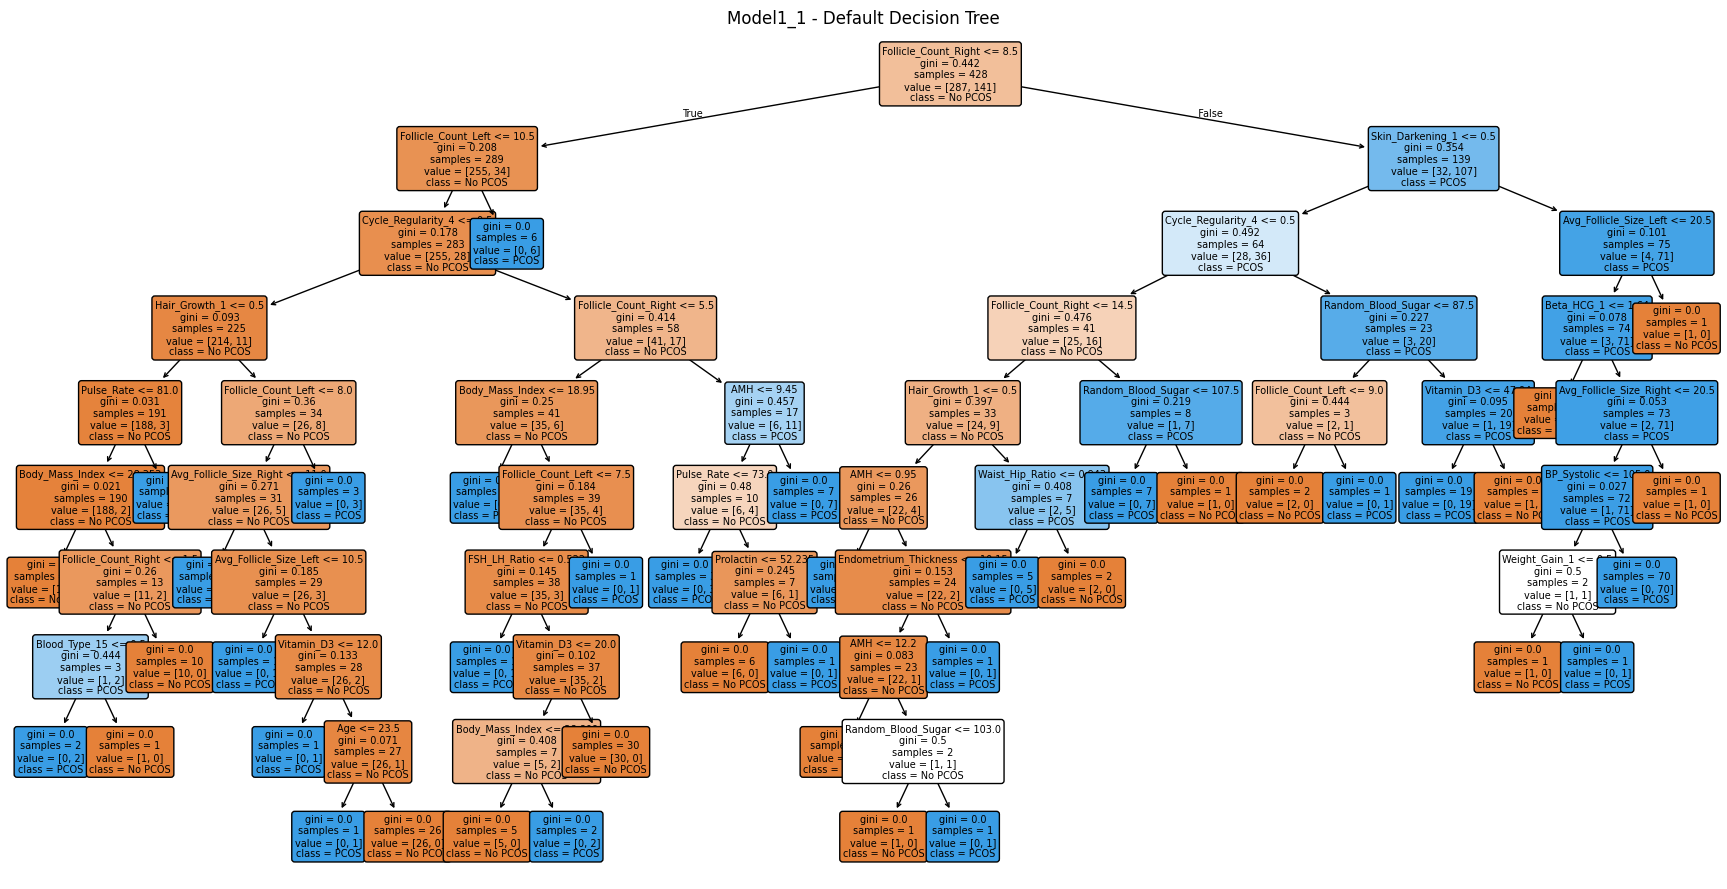

Top 10 Feature Importances - Model1_1


,Feature,Importance
37,Follicle_Count_Right,0.489589
36,Follicle_Count_Left,0.086597
7,Cycle_Regularity_4,0.064891
11,Skin_Darkening_1,0.053902
29,AMH,0.036914
17,Body_Mass_Index,0.034346
10,Hair_Growth_1,0.033041
18,Pulse_Rate,0.026619
39,Avg_Follicle_Size_Right,0.026050
33,Random_Blood_Sugar,0.025035


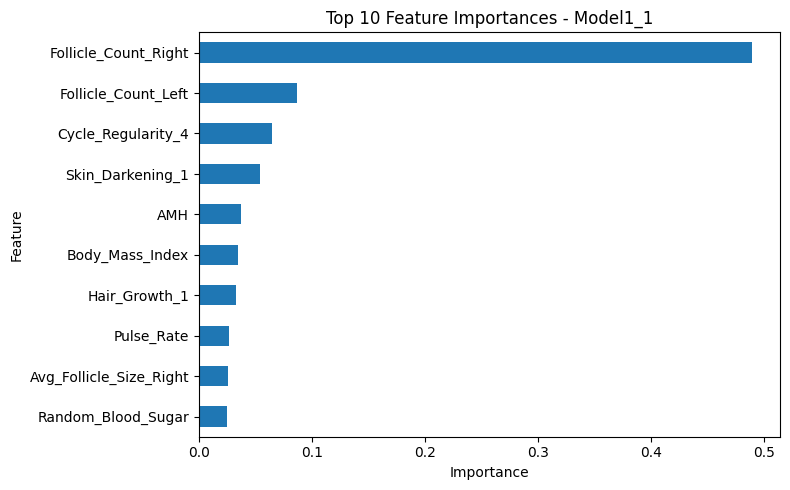

In [ ]:
Model1_1 = DecisionTreeClassifier(random_state=42)
Model1_1.fit(X_train_combined, y_train)

pred1_1 = evaluate_model("Model1_1 - Default Decision Tree", Model1_1, X_test_combined, y_test)
plot_decision_tree("Model1_1 - Default Decision Tree", Model1_1, X_train_combined.columns)
fi1_1 = show_feature_importance("Model1_1", Model1_1, X_train_combined.columns)

## ROC Curve for Model 1_1

So far, we have evaluated the Decision Tree using a single set of final predictions: PCOS = 0 or PCOS = 1. However, a classifier can also provide a predicted probability for the positive class.

For example, the model might produce:

| Patient | Predicted Probability of PCOS |
| ------- | ----------------------------: |
| A       |                          0.10 |
| B       |                          0.35 |
| C       |                          0.48 |
| D       |                          0.67 |
| E       |                          0.91 |

To convert these probabilities into final class predictions, a classification threshold is required. For example, using a threshold of 0.50:

* Probability < 0.50 then predict PCOS = 0
* Probability ≥ 0.50 then predict PCOS = 1

Changing this threshold changes the model's classifications. For example, lowering the threshold from 0.50 to 0.30 will generally identify more positive cases, but it may also incorrectly classify more negative cases as positive.

> The Receiver Operating Characteristic (ROC) curve evaluates this trade-off across many possible classification thresholds.

For each threshold, two quantities are calculated:

* True Positive Rate (TPR) - the proportion of actual positive cases correctly identified by the model. This is also called Recall or Sensitivity.

* False Positive Rate (FPR) - the proportion of actual negative cases incorrectly classified as positive.

> The ROC curve plots:

> True Positive Rate (Sensitivity) on the vertical axis

against

> False Positive Rate on the horizontal axis.

A model with good class-separation ability will achieve a high True Positive Rate while maintaining a relatively low False Positive Rate. Therefore, ROC curves that move toward the `upper-left corner` generally indicate better discrimination.

The diagonal line from (0,0) to (1,1) represents performance similar to `random classification`.

### Area Under the ROC Curve (AUC)

The **Area Under the Curve (AUC)** summarizes the ROC curve into a single value.

In general:

* `AUC = 1.0 then perfect class discrimination
* AUC ~ 0.5 then discrimination similar to random guessing
* Higher AUC values then better ability to distinguish positive from negative cases.

AUC should therefore be interpreted as a measure of the model's ability to separate or rank the two classes across possible thresholds, rather than its accuracy at one particular threshold.

### Why use predicted probabilities?

An ROC curve should be calculated using a continuous prediction score, such as the predicted probability of the positive class:

```python
y_prob = Model1_1.predict_proba(X_test_combined)[:, 1]
```

rather than the final class predictions:

```python
y_pred = Model1_1.predict(X_test_combined)
```

The 0/1 predictions have already applied a classification decision and therefore contain very little information about how model performance changes as the threshold changes.

Predicted probabilities allow us to test many thresholds and observe the resulting trade-off between detecting positive cases and producing false positives.

This distinction is particularly important in applications such as medical diagnosis, where the consequences of a false negative and a false positive may be very different.


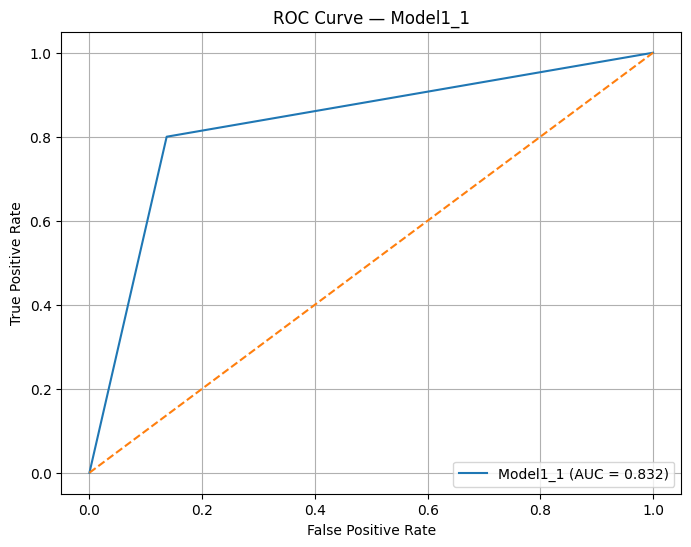

ROC AUC: 0.8315


In [ ]:
y_prob_1_1 = Model1_1.predict_proba(X_test_combined)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_1_1)
auc_1_1 = roc_auc_score(y_test, y_prob_1_1)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Model1_1 (AUC = {auc_1_1:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model1_1")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"ROC AUC: {auc_1_1:.4f}")

## Model1_2 - Change the Criterion to Entropy

`criterion="entropy"` evaluates potential splits using information gain rather than Gini impurity.

**Why change it?**  
Gini impurity and entropy are two different measures of node impurity. They often produce similar trees, but not always. Comparing them lets us determine whether the way split quality is measured affects the resulting classification performance.

## Model 1_2 - Change the Criterion to Entropy

In Model1_1, the Decision Tree used `Gini impurity` to determine the best split. In Model1_2, we change the criterion to:

```python
criterion = "entropy"
```

**Entropy** is another way of measuring how mixed the classes are within a node:

$$
Entropy=-\sum p_i\log_2(p_i)
$$

For a binary classification problem:

* **Entropy = 0** then the node is completely pure.
* **Entropy = 1** then the node is maximally mixed (50% Class 0 and 50% Class 1).

When entropy is used, the tree selects the split that produces the greatest reduction in entropy. This reduction is called Information Gain:



Therefore, the tree chooses the feature and threshold that maximize Information Gain.

### Why change from Gini to Entropy?

Gini impurity and entropy have the same general purpose: both measure how well a potential split separates the classes. However, because they calculate impurity differently, they may occasionally select different features or thresholds.

By comparing Model1_1 and Model1_2, we can determine whether changing the splitting criterion has a meaningful effect on the tree and its predictive performance.


Model1_2 - Entropy
------------------

Confusion Matrix:
[[61 12]
 [ 9 26]]

Accuracy: 0.8056
F1 Score: 0.7123

Classification Report:
              precision    recall  f1-score   support

           0     0.8714    0.8356    0.8531        73
           1     0.6842    0.7429    0.7123        35

    accuracy                         0.8056       108
   macro avg     0.7778    0.7892    0.7827       108
weighted avg     0.8108    0.8056    0.8075       108



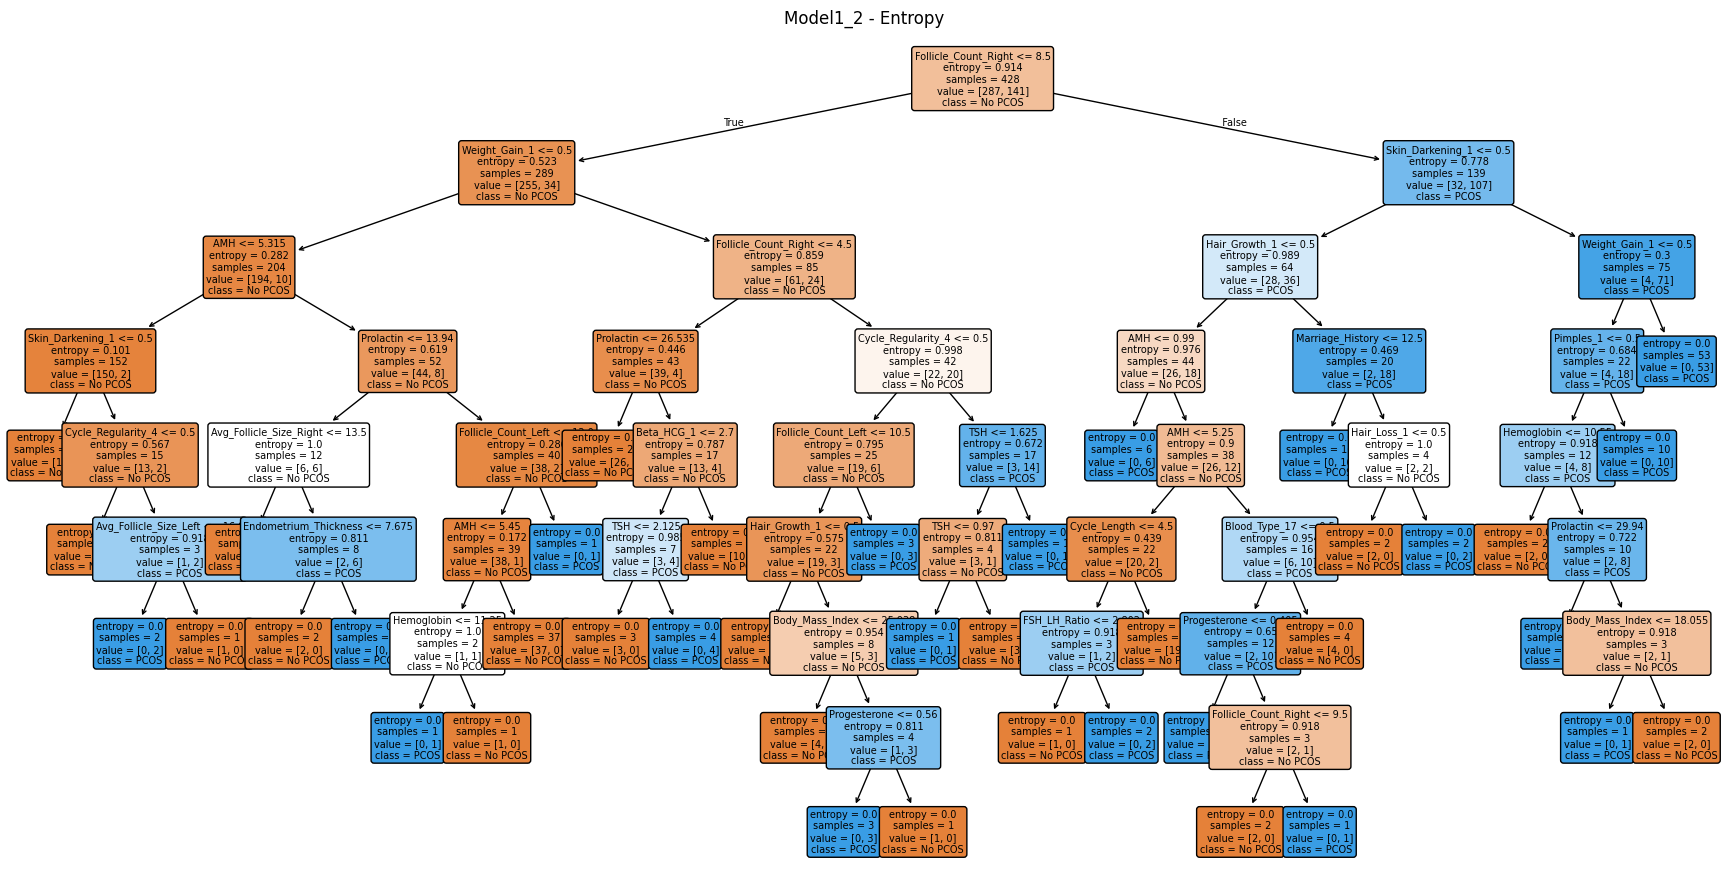

Top 10 Feature Importances - Model1_2


,Feature,Importance
37,Follicle_Count_Right,0.374956
29,AMH,0.083601
11,Skin_Darkening_1,0.074754
9,Weight_Gain_1,0.071404
30,Prolactin,0.048637
28,TSH,0.046828
7,Cycle_Regularity_4,0.041828
10,Hair_Growth_1,0.040779
36,Follicle_Count_Left,0.030614
32,Progesterone,0.021185


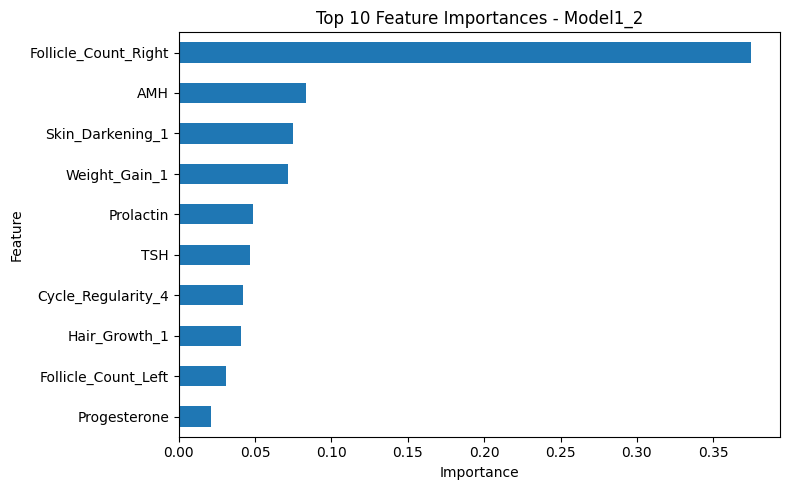

In [ ]:
Model1_2 = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
Model1_2.fit(X_train_combined, y_train)

pred1_2 = evaluate_model("Model1_2 - Entropy", Model1_2, X_test_combined, y_test)
plot_decision_tree("Model1_2 - Entropy", Model1_2, X_train_combined.columns)
fi1_2 = show_feature_importance("Model1_2", Model1_2, X_train_combined.columns)

## Model1_3 - Add Balanced Class Weights

Our target variable is **imbalanced**, meaning that the dataset contains more Class 0 observations than Class 1 observations.

With:

```python
class_weight = "balanced"
```

the Decision Tree automatically gives more importance to the less frequent class and less importance to the more frequent class during training.

### Why use balanced class weights?

Without class weighting, the model may favour the majority class because correctly predicting that class can produce high overall accuracy.

Balanced class weights make errors involving the minority class*more costly to the model. This encourages the tree to pay more attention to correctly identifying minority-class observations.

However, class weighting does not guarantee better performance. We compare Model1_3 with the previous models to determine whether balancing the classes improves metrics such as recall, F1 score, and the confusion matrix.


Model1_3 — Entropy + Balanced
-----------------------------

Confusion Matrix:
[[63 10]
 [ 6 29]]

Accuracy: 0.8519
F1 Score: 0.7838

Classification Report:
              precision    recall  f1-score   support

           0     0.9130    0.8630    0.8873        73
           1     0.7436    0.8286    0.7838        35

    accuracy                         0.8519       108
   macro avg     0.8283    0.8458    0.8356       108
weighted avg     0.8581    0.8519    0.8538       108



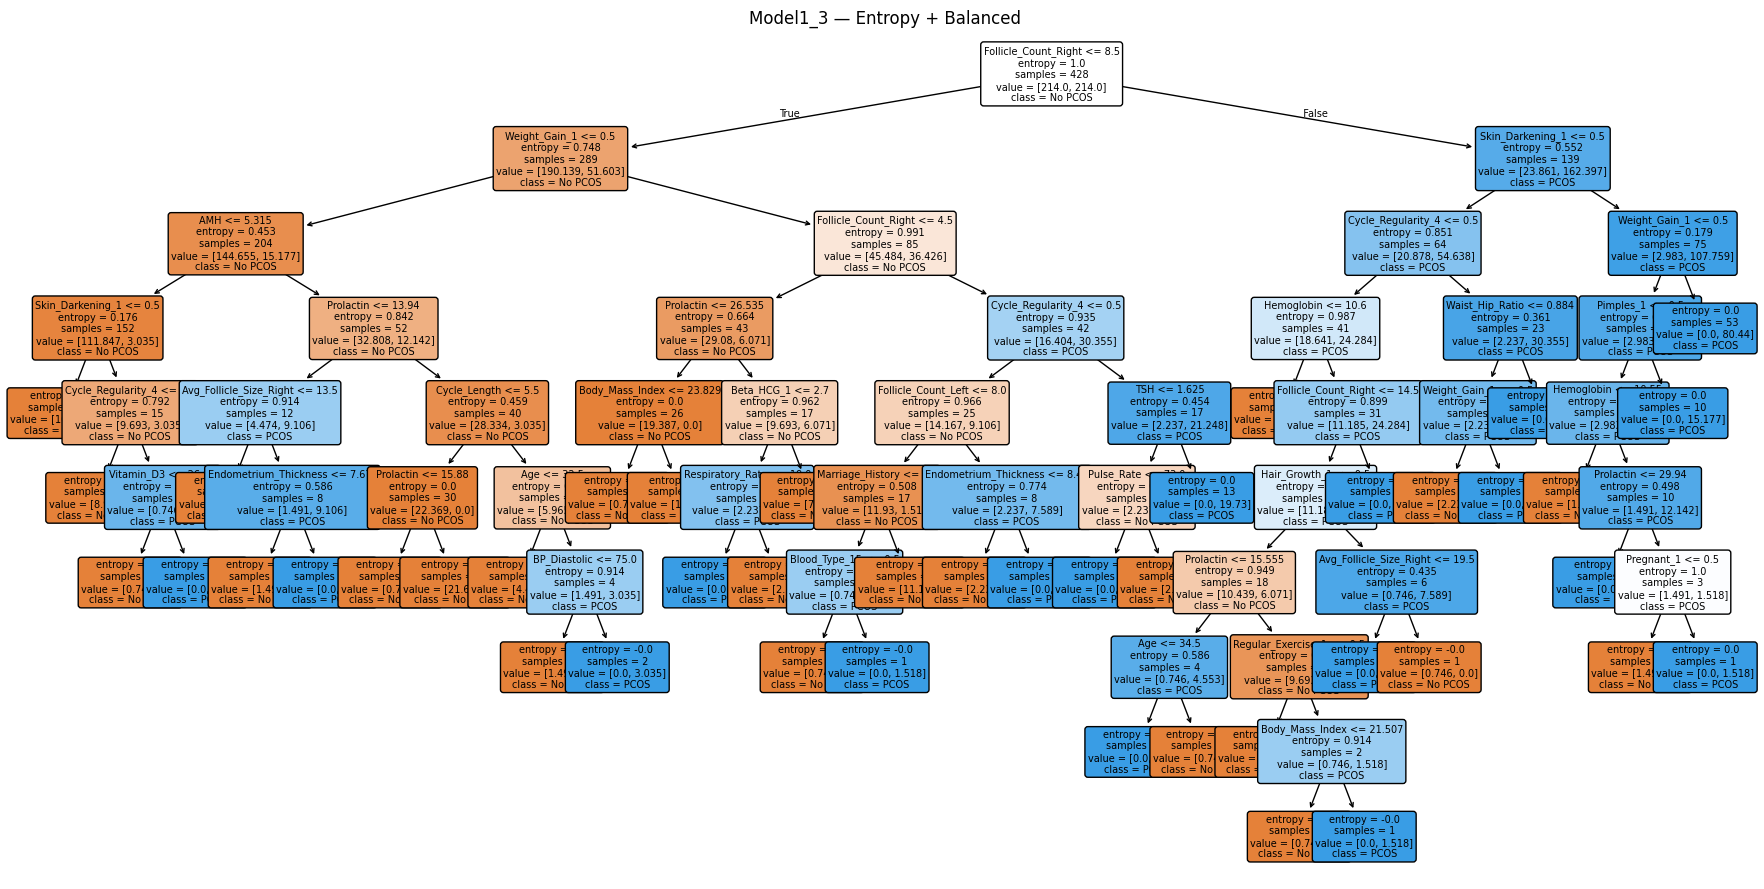

Top 10 Feature Importances - Model1_3


,Feature,Importance
37,Follicle_Count_Right,0.387099
9,Weight_Gain_1,0.094901
30,Prolactin,0.068067
11,Skin_Darkening_1,0.067686
7,Cycle_Regularity_4,0.065528
20,Hemoglobin,0.033965
29,AMH,0.033430
40,Endometrium_Thickness,0.032280
39,Avg_Follicle_Size_Right,0.022964
24,Beta_HCG_1,0.019104


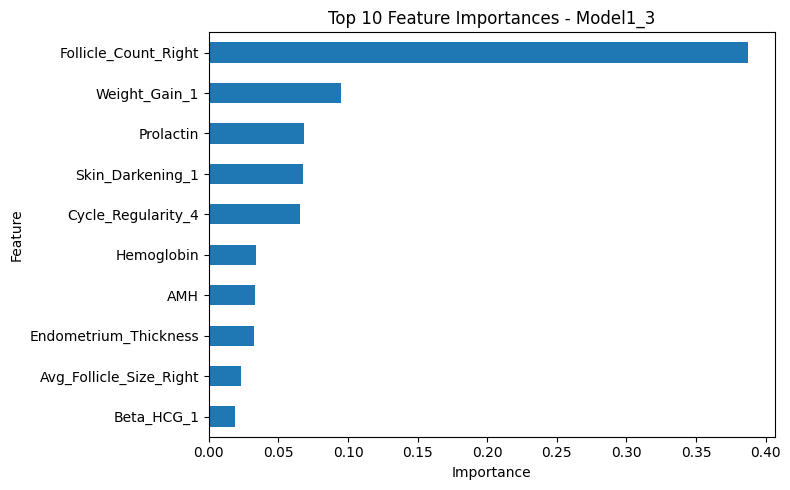

In [ ]:
Model1_3 = DecisionTreeClassifier(
    criterion="entropy",
    class_weight="balanced",
    random_state=42
)
Model1_3.fit(X_train_combined, y_train)

pred1_3 = evaluate_model("Model1_3 — Entropy + Balanced", Model1_3, X_test_combined, y_test)
plot_decision_tree("Model1_3 — Entropy + Balanced", Model1_3, X_train_combined.columns)
fi1_3 = show_feature_importance("Model1_3", Model1_3, X_train_combined.columns)

## Model1_4 - Change `max_depth`

The `max_depth` parameter controls how deep the Decision Tree is allowed to grow.

With:

```python
max_depth = 5
```

the tree can have a maximum depth of 5 levels.

### Why change `max_depth`?

`A very deep tree can create many detailed splits and may **overfit** the training data.`

Limiting the depth makes the tree simpler and can improve its ability to generalize to new data. However, if `max_depth` is too small, the tree may become too simple and underfit the data.

Therefore, `max_depth` helps control the trade-off between:

$$
\boxed{\text{Model Complexity} \leftrightarrow \text{Generalization}}
$$

We compare Model1_4 with Model1_3 to determine whether limiting the tree depth improves test performance.


Model1_4 — max_depth=5
----------------------

Confusion Matrix:
[[58 15]
 [ 7 28]]

Accuracy: 0.7963
F1 Score: 0.7179

Classification Report:
              precision    recall  f1-score   support

           0     0.8923    0.7945    0.8406        73
           1     0.6512    0.8000    0.7179        35

    accuracy                         0.7963       108
   macro avg     0.7717    0.7973    0.7793       108
weighted avg     0.8142    0.7963    0.8008       108



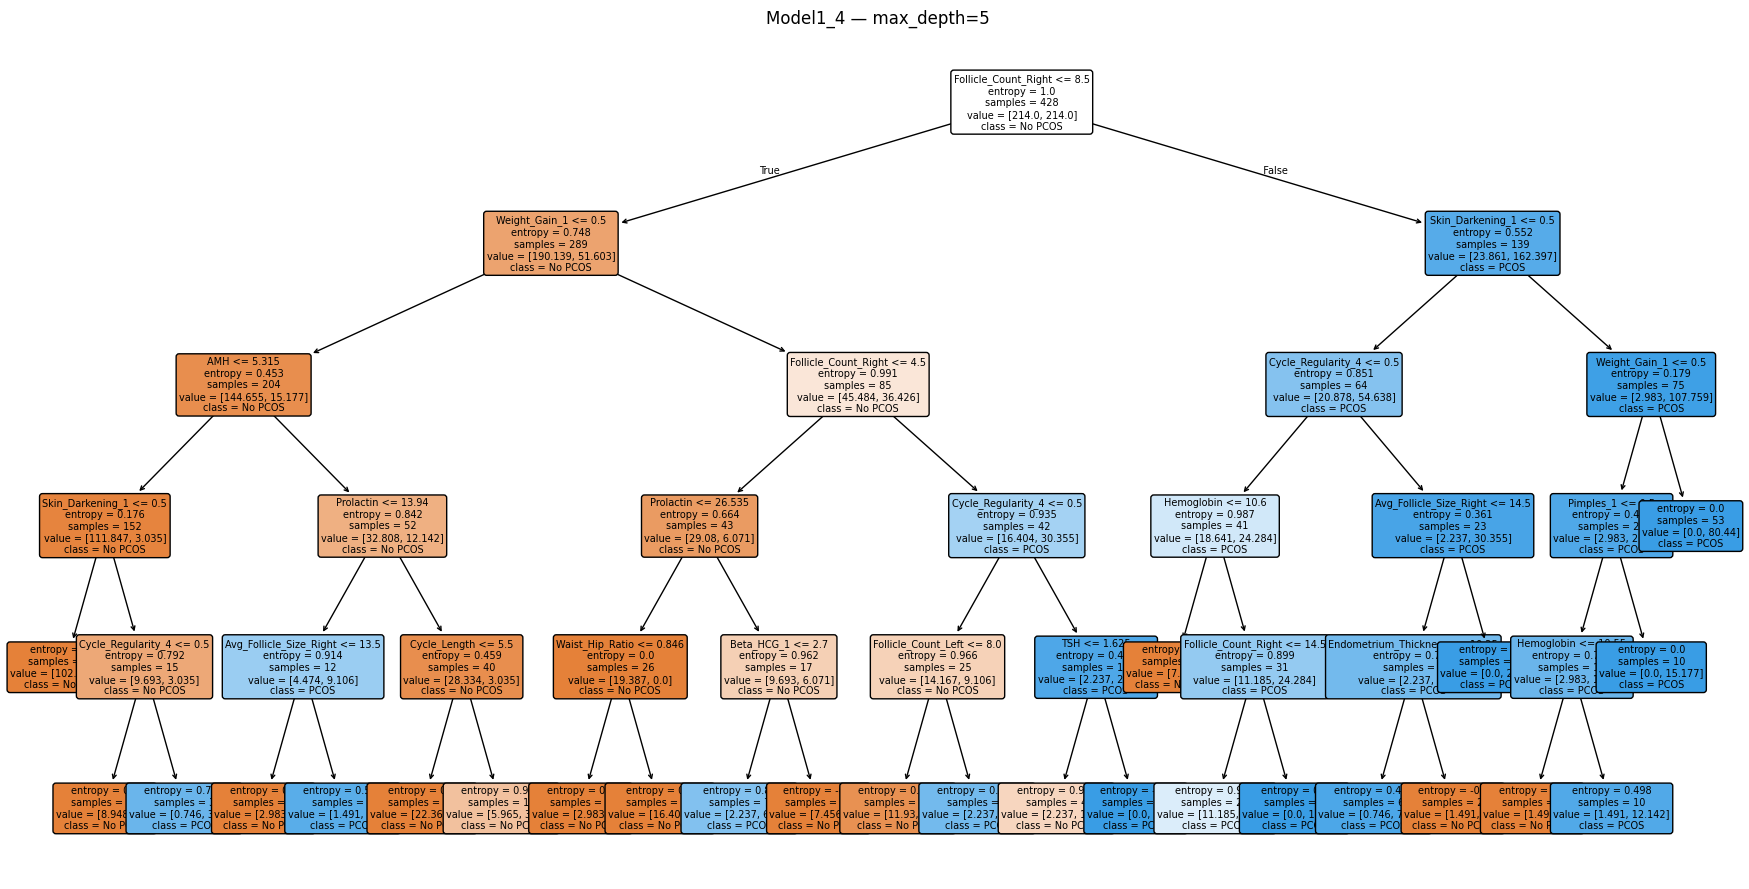

Top 10 Feature Importances - Model1_4


,Feature,Importance
37,Follicle_Count_Right,0.472527
9,Weight_Gain_1,0.094157
11,Skin_Darkening_1,0.082623
7,Cycle_Regularity_4,0.079989
30,Prolactin,0.054770
20,Hemoglobin,0.041460
29,AMH,0.040808
39,Avg_Follicle_Size_Right,0.029550
24,Beta_HCG_1,0.023320
36,Follicle_Count_Left,0.022906


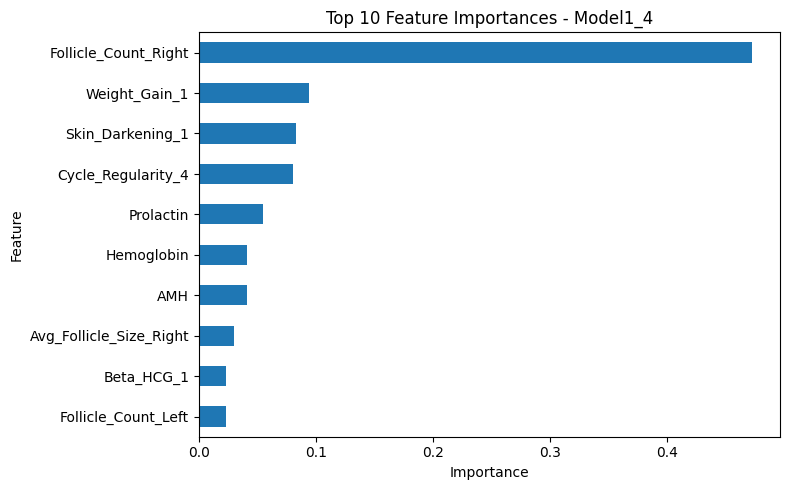

In [ ]:
Model1_4 = DecisionTreeClassifier(
    criterion="entropy",
    class_weight="balanced",
    max_depth=5,
    random_state=42
)
Model1_4.fit(X_train_combined, y_train)

pred1_4 = evaluate_model("Model1_4 — max_depth=5", Model1_4, X_test_combined, y_test)
plot_decision_tree("Model1_4 — max_depth=5", Model1_4, X_train_combined.columns)
fi1_4 = show_feature_importance("Model1_4", Model1_4, X_train_combined.columns)

## Model1_5 - Change `min_samples_split`

The `min_samples_split` parameter controls the minimum number of observations a node must contain before the tree is allowed to split it further.

With:

```python
min_samples_split = 10
```

a node must contain at least 10 observations to be considered for another split. If it contains fewer than 10, it becomes a leaf and will not split further.

### Why change `min_samples_split`?

A tree that continues splitting very small groups can become overly complex and overfit the training data.

Increasing `min_samples_split` makes the tree more conservative by preventing splits based on very small groups of observations.

However, setting it too high may prevent useful splits and lead to underfitting.

We compare Model1_5 with Model1_3 to determine whether restricting small splits improves the model's performance on unseen data.


Model1_5 — min_samples_split=10
-------------------------------

Confusion Matrix:
[[59 14]
 [ 9 26]]

Accuracy: 0.7870
F1 Score: 0.6933

Classification Report:
              precision    recall  f1-score   support

           0     0.8676    0.8082    0.8369        73
           1     0.6500    0.7429    0.6933        35

    accuracy                         0.7870       108
   macro avg     0.7588    0.7755    0.7651       108
weighted avg     0.7971    0.7870    0.7904       108



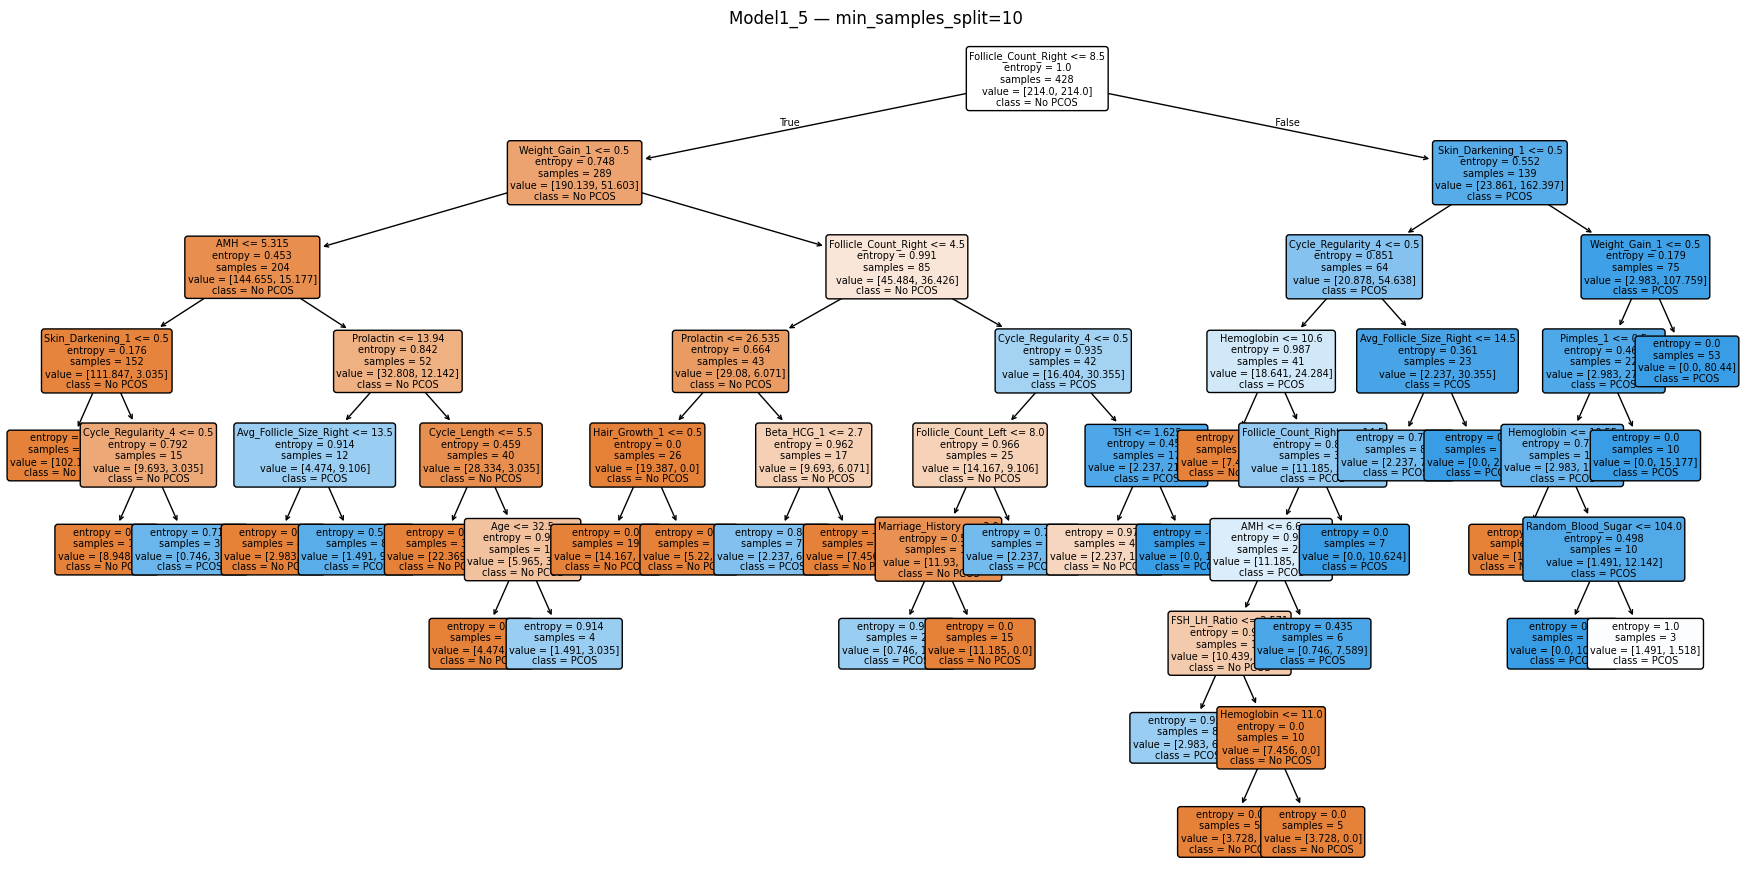

Top 10 Feature Importances - Model1_5


,Feature,Importance
37,Follicle_Count_Right,0.445232
9,Weight_Gain_1,0.088718
11,Skin_Darkening_1,0.077851
7,Cycle_Regularity_4,0.075369
29,AMH,0.052901
30,Prolactin,0.051607
20,Hemoglobin,0.039065
39,Avg_Follicle_Size_Right,0.027843
24,Beta_HCG_1,0.021973
36,Follicle_Count_Left,0.021582


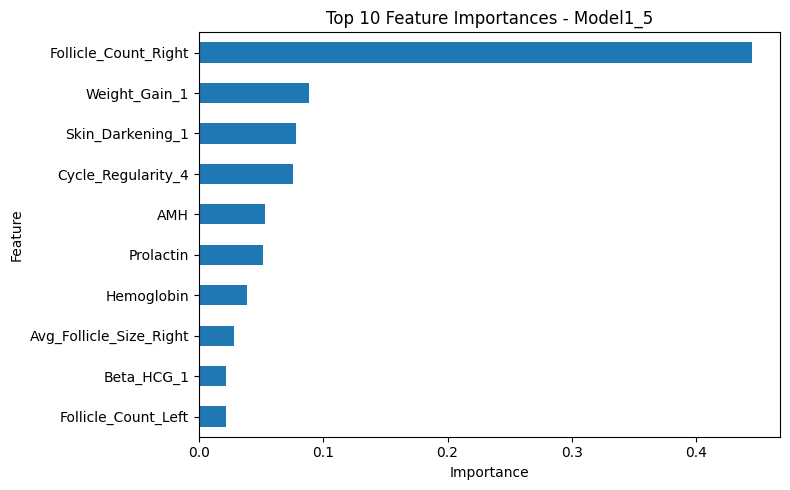

In [ ]:
Model1_5 = DecisionTreeClassifier(
    criterion="entropy",
    class_weight="balanced",
    min_samples_split=10,
    random_state=42
)
Model1_5.fit(X_train_combined, y_train)

pred1_5 = evaluate_model("Model1_5 — min_samples_split=10", Model1_5, X_test_combined, y_test)
plot_decision_tree("Model1_5 — min_samples_split=10", Model1_5, X_train_combined.columns)
fi1_5 = show_feature_importance("Model1_5", Model1_5, X_train_combined.columns)

## Model1_6 - Change `min_samples_leaf`

The `min_samples_leaf` parameter controls the minimum number of observations that must remain in each leaf after a split.

With:

```python
min_samples_leaf = 2
```

every final leaf must contain at least 2 training observations.

### Why change `min_samples_leaf`?

Allowing leaves with only one observation can make the tree overly specific to the training data and increase the risk of overfitting.

Increasing `min_samples_leaf` prevents very small leaves and generally produces a simpler, more stable tree.

However, setting it too high can make the tree too restrictive and lead to underfitting.

We compare Model1_6 with Model1_3 to determine whether preventing very small leaves improves performance on unseen data.


Model1_6 — min_samples_leaf=2
-----------------------------

Confusion Matrix:
[[60 13]
 [ 7 28]]

Accuracy: 0.8148
F1 Score: 0.7368

Classification Report:
              precision    recall  f1-score   support

           0     0.8955    0.8219    0.8571        73
           1     0.6829    0.8000    0.7368        35

    accuracy                         0.8148       108
   macro avg     0.7892    0.8110    0.7970       108
weighted avg     0.8266    0.8148    0.8182       108



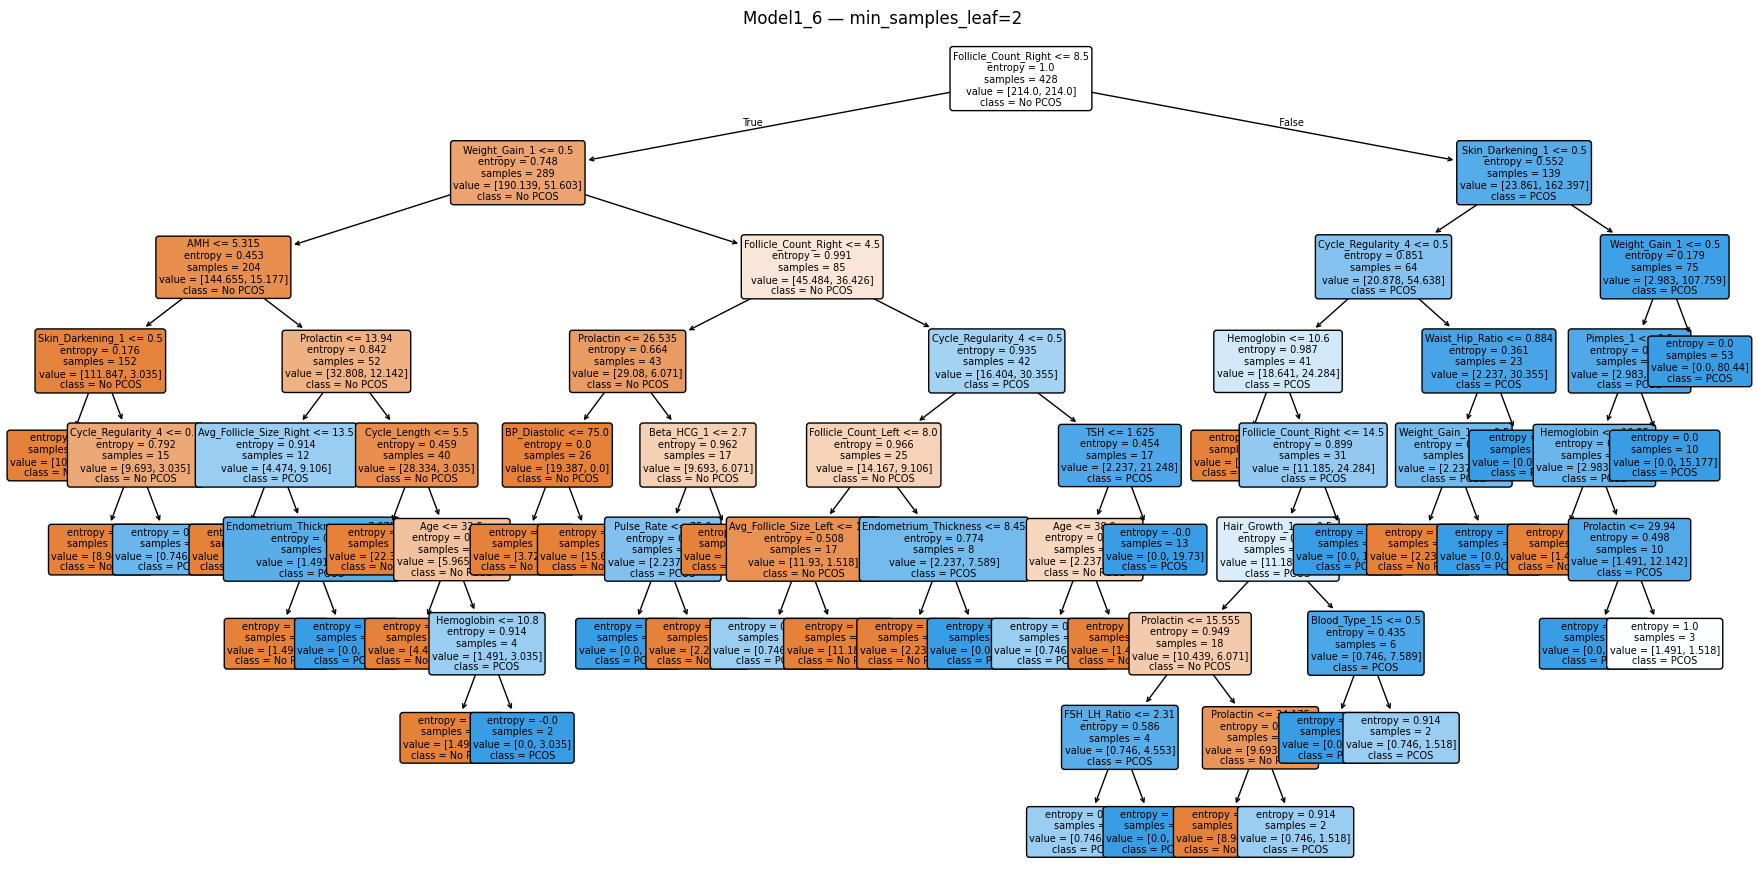

Top 10 Feature Importances - Model1_6


,Feature,Importance
37,Follicle_Count_Right,0.402195
9,Weight_Gain_1,0.098602
30,Prolactin,0.081265
11,Skin_Darkening_1,0.070326
7,Cycle_Regularity_4,0.068083
20,Hemoglobin,0.045337
29,AMH,0.034734
40,Endometrium_Thickness,0.033538
24,Beta_HCG_1,0.019849
36,Follicle_Count_Left,0.019496


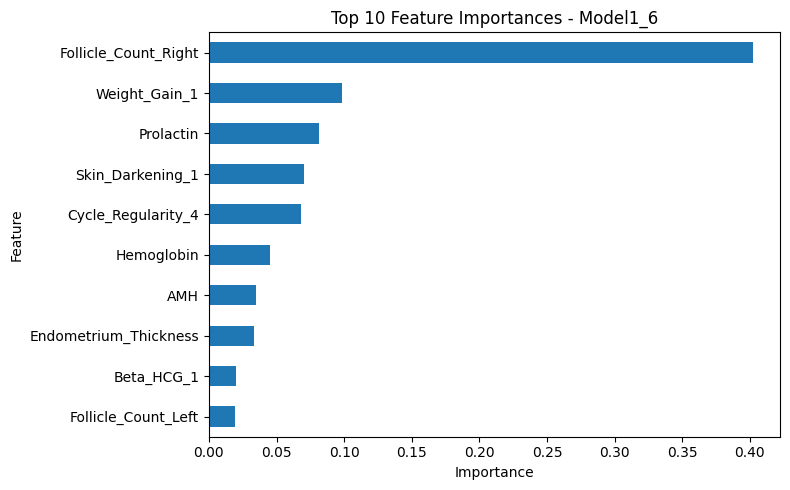

In [ ]:
Model1_6 = DecisionTreeClassifier(
    criterion="entropy",
    class_weight="balanced",
    min_samples_leaf=2,
    random_state=42
)
Model1_6.fit(X_train_combined, y_train)

pred1_6 = evaluate_model("Model1_6 — min_samples_leaf=2", Model1_6, X_test_combined, y_test)
plot_decision_tree("Model1_6 — min_samples_leaf=2", Model1_6, X_train_combined.columns)
fi1_6 = show_feature_importance("Model1_6", Model1_6, X_train_combined.columns)

## Decision Tree Comparison

In [ ]:
model_keys = {
    1: "Model1_1 - Default Decision Tree",
    2: "Model1_2 - Entropy",
    3: "Model1_3 — Entropy + Balanced",
    4: "Model1_4 — max_depth=5",
    5: "Model1_5 — min_samples_split=10",
    6: "Model1_6 — min_samples_leaf=2"
}

decision_tree_results = pd.DataFrame(model_results).T.loc[
    [model_keys[i] for i in range(1, 7)]
]

decision_tree_results.sort_values("F1 Score", ascending=False)

,Accuracy,F1 Score
Model1_3 — Entropy + Balanced,0.851852,0.783784
Model1_1 - Default Decision Tree,0.842593,0.767123
Model1_6 — min_samples_leaf=2,0.814815,0.736842
Model1_4 — max_depth=5,0.796296,0.717949
Model1_2 - Entropy,0.805556,0.712329
Model1_5 — min_samples_split=10,0.787037,0.693333


### Decision Tree Interpretation

Changing a hyperparameter does **not** guarantee improvement. The purpose of these models is to see how the tree reacts when the impurity criterion, class weighting, and stopping conditions change.

When comparing the models, consider both:
- overall predictive performance, and
- the balance between false positives and false negatives in the confusion matrix.

For a medical diagnosis problem, a false negative can be particularly important because it represents a patient with PCOS who was classified as not having PCOS. The relative cost of false negatives and false positives should therefore be considered alongside accuracy.

# Stage 3 - Random Forest Models

A Random Forest is an ensemble of many Decision Trees. Each tree is trained on a bootstrap sample of the training data, and only a subset of features is considered at each split. Averaging across many diverse trees usually reduces the variance associated with a single Decision Tree.

## Model2_1 - Default Random Forest

Model2_1 — Default Random Forest
--------------------------------

Confusion Matrix:
[[68  5]
 [10 25]]

Accuracy: 0.8611
F1 Score: 0.7692

Classification Report:
              precision    recall  f1-score   support

           0     0.8718    0.9315    0.9007        73
           1     0.8333    0.7143    0.7692        35

    accuracy                         0.8611       108
   macro avg     0.8526    0.8229    0.8349       108
weighted avg     0.8593    0.8611    0.8581       108

Top 10 Feature Importances - Model2_1


,Feature,Importance
37,Follicle_Count_Right,0.184414
36,Follicle_Count_Left,0.157995
11,Skin_Darkening_1,0.055403
10,Hair_Growth_1,0.054363
9,Weight_Gain_1,0.047235
29,AMH,0.035299
21,Cycle_Length,0.033775
17,Body_Mass_Index,0.026960
7,Cycle_Regularity_4,0.026351
26,FSH_LH_Ratio,0.026348


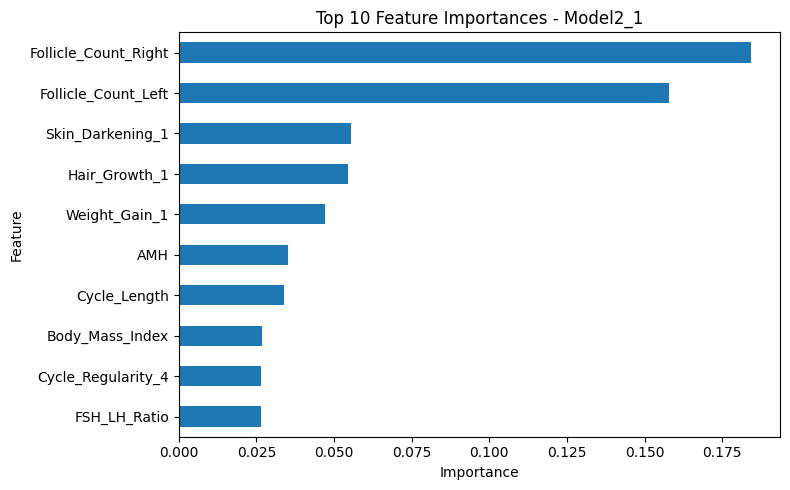

In [ ]:
Model2_1 = RandomForestClassifier(random_state=42)
Model2_1.fit(X_train_combined, y_train)

pred2_1 = evaluate_model("Model2_1 — Default Random Forest", Model2_1, X_test_combined, y_test)
fi2_1 = show_feature_importance("Model2_1", Model2_1, X_train_combined.columns)

## Model2_2 - Entropy + Balanced Class Weights

This model changes two settings from the default Random Forest:

- `criterion="entropy"` changes how split quality is measured.
- `class_weight="balanced"` gives more influence to the minority class.

**Why?**  
The criterion change tests whether information gain produces more useful splits, while balanced class weights address the unequal number of Class 0 and Class 1 observations.

Model2_2 — Entropy + Balanced
-----------------------------

Confusion Matrix:
[[68  5]
 [13 22]]

Accuracy: 0.8333
F1 Score: 0.7097

Classification Report:
              precision    recall  f1-score   support

           0     0.8395    0.9315    0.8831        73
           1     0.8148    0.6286    0.7097        35

    accuracy                         0.8333       108
   macro avg     0.8272    0.7800    0.7964       108
weighted avg     0.8315    0.8333    0.8269       108

Top 10 Feature Importances - Model2_2


,Feature,Importance
37,Follicle_Count_Right,0.177253
36,Follicle_Count_Left,0.122780
9,Weight_Gain_1,0.053626
11,Skin_Darkening_1,0.053007
10,Hair_Growth_1,0.047921
29,AMH,0.044987
21,Cycle_Length,0.031923
17,Body_Mass_Index,0.030317
31,Vitamin_D3,0.028285
28,TSH,0.028200


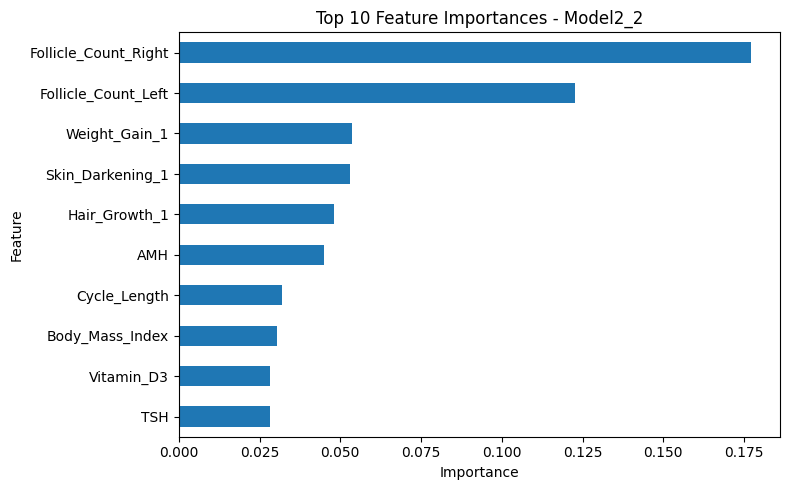

In [ ]:
Model2_2 = RandomForestClassifier(
    criterion="entropy",
    class_weight="balanced",
    random_state=42
)
Model2_2.fit(X_train_combined, y_train)

pred2_2 = evaluate_model("Model2_2 — Entropy + Balanced", Model2_2, X_test_combined, y_test)
fi2_2 = show_feature_importance("Model2_2", Model2_2, X_train_combined.columns)

## Model2_3 - Change `max_features` to `log2`

`max_features` controls how many candidate predictors are considered at each split.

With `max_features="log2"`, fewer predictors are considered at each split than with the default `"sqrt"` for this dataset.

**Why can this matter?**  
Restricting the candidate features can make the individual trees less similar to one another. Greater diversity among trees can improve the ensemble because the trees are less likely to make exactly the same errors. However, restricting features too much can also weaken individual trees.

Model2_3 — max_features='log2'
------------------------------

Confusion Matrix:
[[70  3]
 [11 24]]

Accuracy: 0.8704
F1 Score: 0.7742

Classification Report:
              precision    recall  f1-score   support

           0     0.8642    0.9589    0.9091        73
           1     0.8889    0.6857    0.7742        35

    accuracy                         0.8704       108
   macro avg     0.8765    0.8223    0.8416       108
weighted avg     0.8722    0.8704    0.8654       108

Top 10 Feature Importances - Model2_3


,Feature,Importance
37,Follicle_Count_Right,0.167367
36,Follicle_Count_Left,0.112476
11,Skin_Darkening_1,0.059783
29,AMH,0.050164
10,Hair_Growth_1,0.049517
9,Weight_Gain_1,0.045728
21,Cycle_Length,0.034385
31,Vitamin_D3,0.030716
7,Cycle_Regularity_4,0.030715
17,Body_Mass_Index,0.029055


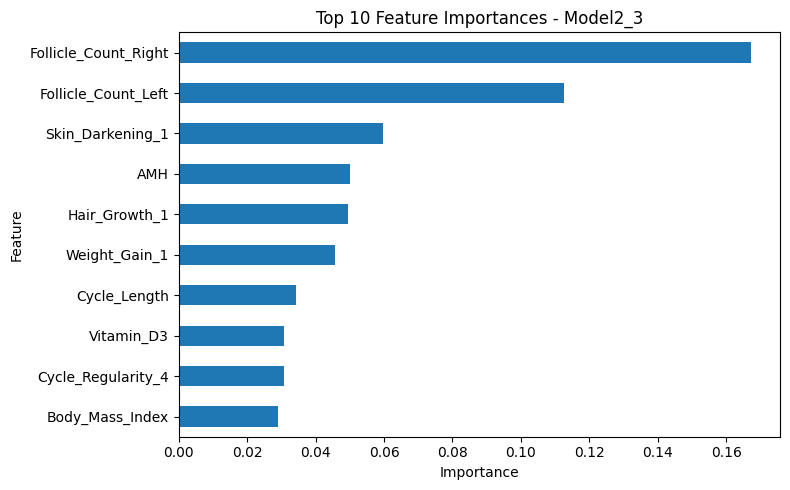

In [ ]:
Model2_3 = RandomForestClassifier(
    criterion="entropy",
    class_weight="balanced",
    max_features="log2",
    random_state=42
)
Model2_3.fit(X_train_combined, y_train)

pred2_3 = evaluate_model("Model2_3 — max_features='log2'", Model2_3, X_test_combined, y_test)
fi2_3 = show_feature_importance("Model2_3", Model2_3, X_train_combined.columns)

## Random Forest Comparison

In [ ]:
random_forest_results = pd.DataFrame(model_results).T.loc[
    [
        "Model2_1 — Default Random Forest",
        "Model2_2 — Entropy + Balanced",
        "Model2_3 — max_features='log2'"
    ]
]

random_forest_results.sort_values("F1 Score", ascending=False)

,Accuracy,F1 Score
Model2_3 — max_features='log2',0.870370,0.774194
Model2_1 — Default Random Forest,0.861111,0.769231
Model2_2 — Entropy + Balanced,0.833333,0.709677


# Stage 4 - Extreme Gradient Boosting (XGBoost)

XGBoost also combines many trees, but it uses **boosting** rather than the independent-tree averaging used by Random Forest. Trees are added sequentially so that later trees focus on correcting errors made by the current ensemble.

## Model3_1 - Default XGBoost

Model3_1 — Default XGBoost
--------------------------

Confusion Matrix:
[[68  5]
 [10 25]]

Accuracy: 0.8611
F1 Score: 0.7692

Classification Report:
              precision    recall  f1-score   support

           0     0.8718    0.9315    0.9007        73
           1     0.8333    0.7143    0.7692        35

    accuracy                         0.8611       108
   macro avg     0.8526    0.8229    0.8349       108
weighted avg     0.8593    0.8611    0.8581       108

Top 10 Feature Importances - Model3_1


,Feature,Importance
37,Follicle_Count_Right,0.197926
36,Follicle_Count_Left,0.080721
9,Weight_Gain_1,0.070679
11,Skin_Darkening_1,0.054681
15,Regular_Exercise_1,0.052986
7,Cycle_Regularity_4,0.051594
10,Hair_Growth_1,0.049084
17,Body_Mass_Index,0.041640
28,TSH,0.033529
21,Cycle_Length,0.033411


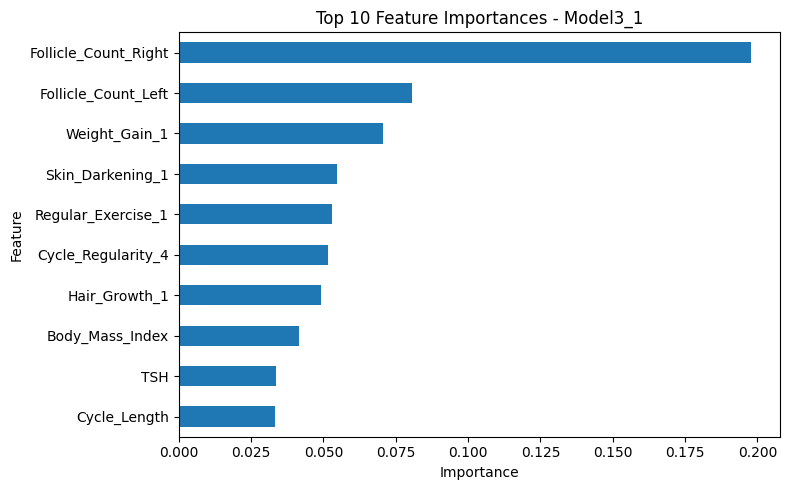

In [ ]:
Model3_1 = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
Model3_1.fit(X_train_combined, y_train)

pred3_1 = evaluate_model("Model3_1 — Default XGBoost", Model3_1, X_test_combined, y_test)
fi3_1 = show_feature_importance("Model3_1", Model3_1, X_train_combined.columns)

## Model3_2 - Adjust `scale_pos_weight`

For binary classification, a commonly used starting value is:
$$
\
\text{scale\_pos\_weight}
=
\frac{\text{number of negative training cases}}
{\text{number of positive training cases}}
\
$$
The value should be calculated **from the training target only**, not from the full dataset, because model settings should not be derived from the held-out test set.

**Why use it?**  
Increasing `scale_pos_weight` makes errors on positive-class observations more influential during XGBoost training. This can help when the positive class is underrepresented, but it does not guarantee higher accuracy or F1 score.

In [ ]:
class_counts_train = y_train.value_counts()

negative_count = class_counts_train.loc[0]
positive_count = class_counts_train.loc[1]

Positive_Class_Weight = negative_count / positive_count

print("Training Class 0 count:", negative_count)
print("Training Class 1 count:", positive_count)
print(f"scale_pos_weight: {Positive_Class_Weight:.4f}")

Training Class 0 count: 287
Training Class 1 count: 141
scale_pos_weight: 2.0355


Model3_2 — Weighted XGBoost
---------------------------

Confusion Matrix:
[[69  4]
 [ 9 26]]

Accuracy: 0.8796
F1 Score: 0.8000

Classification Report:
              precision    recall  f1-score   support

           0     0.8846    0.9452    0.9139        73
           1     0.8667    0.7429    0.8000        35

    accuracy                         0.8796       108
   macro avg     0.8756    0.8440    0.8570       108
weighted avg     0.8788    0.8796    0.8770       108

Top 10 Feature Importances - Model3_2


,Feature,Importance
37,Follicle_Count_Right,0.200433
9,Weight_Gain_1,0.068626
7,Cycle_Regularity_4,0.061167
36,Follicle_Count_Left,0.058304
10,Hair_Growth_1,0.047421
14,Fast_Food_1,0.039127
28,TSH,0.038498
21,Cycle_Length,0.034905
11,Skin_Darkening_1,0.034267
17,Body_Mass_Index,0.030641


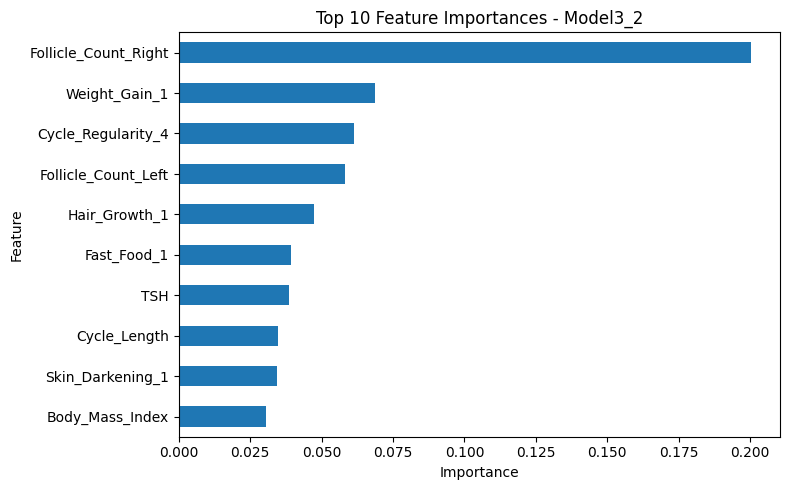

In [ ]:
Model3_2 = XGBClassifier(
    scale_pos_weight=Positive_Class_Weight,
    random_state=42,
    eval_metric="logloss"
)
Model3_2.fit(X_train_combined, y_train)

pred3_2 = evaluate_model("Model3_2 — Weighted XGBoost", Model3_2, X_test_combined, y_test)
fi3_2 = show_feature_importance("Model3_2", Model3_2, X_train_combined.columns)

## XGBoost Comparison

In [ ]:
xgboost_results = pd.DataFrame(model_results).T.loc[
    [
        "Model3_1 — Default XGBoost",
        "Model3_2 — Weighted XGBoost"
    ]
]

xgboost_results.sort_values("F1 Score", ascending=False)

,Accuracy,F1 Score
Model3_2 — Weighted XGBoost,0.879630,0.800000
Model3_1 — Default XGBoost,0.861111,0.769231


# Feature Importance - Interpretation

The `feature_importances_` attribute tells us which predictors were most influential in the fitted tree-based model.

A larger value means the feature contributed more strongly to the model's splitting decisions. However:

1. Feature importance does **not** tell us whether the feature increases or decreases the probability of PCOS.
2. It does **not** establish causation.
3. Importance values can be affected by correlated predictors and by the particular training sample.
4. Different algorithms can assign different levels of importance to the same predictor.

Therefore, feature importance is useful for understanding model behaviour, but it should not be interpreted as clinical proof that a variable causes PCOS.

# Logistic Regression Baseline for Comparison

The activity asks us to compare the tree-based models with logistic regression from Module 6.

For a self-contained reference solution, a logistic-regression baseline is fitted here using the **same encoded predictors and same train/test split**. Because logistic regression is sensitive to feature scale, `StandardScaler` is fitted to the training data within a pipeline before the logistic-regression model.

In [ ]:
Logistic_Model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

Logistic_Model.fit(X_train_combined, y_train)

logistic_pred = Logistic_Model.predict(X_test_combined)

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_f1 = f1_score(y_test, logistic_pred)

print("Logistic Regression Baseline")
print("----------------------------")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))
print(f"\nAccuracy: {logistic_accuracy:.4f}")
print(f"F1 Score: {logistic_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, logistic_pred, digits=4))

model_results["Logistic Regression"] = {
    "Accuracy": logistic_accuracy,
    "F1 Score": logistic_f1
}

Logistic Regression Baseline
----------------------------

Confusion Matrix:
[[68  5]
 [10 25]]

Accuracy: 0.8611
F1 Score: 0.7692

Classification Report:
              precision    recall  f1-score   support

           0     0.8718    0.9315    0.9007        73
           1     0.8333    0.7143    0.7692        35

    accuracy                         0.8611       108
   macro avg     0.8526    0.8229    0.8349       108
weighted avg     0.8593    0.8611    0.8581       108



# Final Model Comparison

In [ ]:
comparison = pd.DataFrame(model_results).T

comparison = comparison.sort_values(
    by=["F1 Score", "Accuracy"],
    ascending=False
)

comparison

,Accuracy,F1 Score
Model3_2 — Weighted XGBoost,0.879630,0.800000
Model1_3 — Entropy + Balanced,0.851852,0.783784
Model2_3 — max_features='log2',0.870370,0.774194
Model2_1 — Default Random Forest,0.861111,0.769231
Model3_1 — Default XGBoost,0.861111,0.769231
Logistic Regression,0.861111,0.769231
Model1_1 - Default Decision Tree,0.842593,0.767123
Model1_6 — min_samples_leaf=2,0.814815,0.736842
Model1_4 — max_depth=5,0.796296,0.717949
Model1_2 - Entropy,0.805556,0.712329


In [ ]:
best_model_name = comparison.index[0]

print("Best model on this test split:", best_model_name)
print(
    f"Accuracy = {comparison.loc[best_model_name, 'Accuracy']:.4f}, "
    f"F1 = {comparison.loc[best_model_name, 'F1 Score']:.4f}"
)

Best model on this test split: Model3_2 — Weighted XGBoost
Accuracy = 0.8796, F1 = 0.8000


# Reflection Questions

## 1. Compared with logistic regression, do tree-based models work better?

**Not on this particular train/test split.**

The logistic-regression baseline achieved:

- Accuracy = **0.9352**
- F1 score = **0.8955**

The best tree-based model was **Model3_2 — Weighted XGBoost**, which achieved:

- Accuracy = **0.9352**
- F1 score = **0.8923**

Therefore, logistic regression tied the best tree-based models in accuracy and produced the highest F1 score overall, although the difference from weighted XGBoost was very small.

This is an important result: more complex algorithms do not automatically outperform a simpler model. The appropriate conclusion is limited to this particular train/test split. Repeated evaluation or cross-validation would be required before making a stronger statement about which method generalizes better.

## 2. Among Decision Tree, Random Forest, and XGBoost, which method works best?

Based on the final comparison table, **Weighted XGBoost (Model3_2)** is the best-performing tree-based model on this test split.

It achieved:

- Accuracy = **0.9352**
- F1 score = **0.8923**

The default Random Forest was extremely close:

- Accuracy = **0.9352**
- F1 score = **0.8889**

Thus, XGBoost has the highest F1 score among the three tree-based approaches, while XGBoost and Random Forest tie in accuracy. Both ensemble methods substantially outperform the individual Decision Tree models on this split.

The comparison should not rely on accuracy alone. Because PCOS is the positive and less frequent class, F1 score and the number of false negatives are especially informative.

## 3. If Random Forest and XGBoost are more advanced tree-based ensemble methods, is it still reasonable to model a single Decision Tree?

Yes. A single Decision Tree remains useful because it is:

- highly interpretable;
- easy to visualize;
- computationally inexpensive;
- useful as a baseline;
- useful for explaining recursive partitioning and the effects of tree hyperparameters.

Random Forest and XGBoost can improve predictive performance by combining many trees, but this also makes their internal decision process less transparent. Therefore, model selection depends not only on predictive performance but also on interpretability and the purpose of the analysis.

## 4. What factors not considered here could make the reported model performance questionable or unreliable?

Several limitations should be recognized:

- **Single train/test split:** the ranking of models could change with a different random split.
- **Relatively small dataset:** the test set contains only 108 observations, so a few changed predictions can noticeably change the metrics.
- **No cross-validation:** performance stability across multiple folds has not been evaluated.
- **Limited hyperparameter search:** only selected parameter changes were tested; this is not systematic model tuning.
- **Class imbalance:** although weighting was investigated, the target remains imbalanced and accuracy alone is insufficient.
- **Potential correlated predictors:** correlated variables can affect both model behaviour and feature-importance values.
- **No external validation:** all models were evaluated using observations originating from the same dataset.
- **Clinical interpretation:** predictive association does not imply causation, and a classroom model is not a clinically validated diagnostic system.

A natural next step would be **Stratified K-Fold Cross-Validation**, followed by systematic hyperparameter tuning.

# Key Takeaways

1. Splitting the dataset before fitting the One-Hot Encoder prevents preprocessing leakage.
2. Decision Tree hyperparameters control the trade-off between flexibility and overfitting.
3. Class weighting changes the importance of classification errors but does not guarantee better test performance.
4. Random Forest reduces the instability of a single tree by averaging many diverse trees.
5. XGBoost builds trees sequentially to correct errors made by the existing ensemble.
6. ROC curves should use predicted probabilities rather than hard class predictions.
7. Feature importance describes how the fitted model used predictors; it does not establish causal relationships.
8. Model conclusions based on one train/test split should be treated cautiously; cross-validation provides stronger evidence.